<a href="https://colab.research.google.com/github/luishernandezpw/PrograIII-2024-Semi/blob/bloqueIII/IA_de_numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#importar las librerias necesarias.
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import tensorflow_datasets as tfds

In [5]:
#cargamos el dataset
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
datos_entrenamiento, datos_prueba = dataset['train'], dataset['test']
#print(datos_entrenamiento)

In [6]:
#asignacion de etiquetas
numero_letras = ["Cero", "Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis", "Siete", "Ocho", "Nueve"]

In [10]:
#pasar los datos del dataset a variables
numeros_ejemplo_entrenamiento = metadata.splits['train'].num_examples
#print(numeros_ejemplo_entrenamiento)

numeros_ejemplo_prueba = metadata.splits['test'].num_examples
#print(numeros_ejemplo_prueba)

In [13]:
img = datos_prueba.take(1)
print(img)

<_TakeDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [14]:
#funcion normalizadora de los pixeles de 0 a 255 para que vaya de 0 a 1
def normalizacion(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 # 138/255 = 0.541176
  return imagenes, etiquetas

In [15]:
#normalizamos los datos de entrenamiento y prueba
datos_entrenamiento = datos_entrenamiento.map(normalizacion)
datos_prueba = datos_prueba.map(normalizacion)

In [18]:
#creamos el modelo de nuestra red neuronal.
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
#compilamos el modelo de la red neuronal.
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
#entrenamos la red neuronal por lotes.
tamano_lote = 32 #60,000/32 = 1875 imagenes.
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(numeros_ejemplo_entrenamiento).batch(tamano_lote)
datos_prueba = datos_prueba.repeat().shuffle(numeros_ejemplo_prueba).batch(tamano_lote)
#

In [21]:
#entrenamos nuestro modelo de datos.
modelo.fit(datos_entrenamiento, epochs=5,
           steps_per_epoch=math.ceil(numeros_ejemplo_entrenamiento/tamano_lote))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8611 - loss: 0.4857
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9618 - loss: 0.1250
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9737 - loss: 0.0882
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9788 - loss: 0.0697
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9817 - loss: 0.0605


In [22]:
#evaluamos el modelo.
test_loss, test_accuracy = modelo.evaluate(datos_prueba, steps=math.ceil(numeros_ejemplo_prueba/tamano_lote))
print('Resultado de las pruebas: ', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9705 - loss: 0.0939
Resultado de las pruebas:  0.9733426570892334


In [24]:
#convertir en mtrices las imganes usando numpy
for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)
  print(predicciones)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[1.33367991e-12 2.57477915e-08 1.23490815e-10 1.43784382e-05
  4.37311354e-14 9.99984205e-01 2.94938830e-11 4.81176480e-14
  1.94000371e-09 1.30337207e-06]
 [1.47714999e-07 9.99905050e-01 6.91720743e-07 1.10345958e-07
  7.25688380e-07 3.75968000e-07 2.83784569e-08 7.22220429e-05
  2.05070428e-05 1.43956981e-07]
 [1.82253774e-04 3.65083991e-03 3.45014199e-03 1.36220036e-03
  9.52307237e-05 1.23943362e-04 1.50986443e-05 9.77079809e-01
  5.18327637e-04 1.35220690e-02]
 [2.13326445e-09 1.56489784e-06 1.15747667e-07 3.16626283e-05
  2.42503040e-04 4.75353620e-04 1.13278507e-08 3.88601802e-05
  2.20971215e-05 9.99187768e-01]
 [1.11302842e-08 2.84169619e-05 6.54818941e-05 3.69872674e-02
  1.54715531e-06 3.11802665e-07 3.48857370e-08 5.57203066e-06
  9.62164521e-01 7.46951031e-04]
 [7.99916234e-05 2.66490947e-03 9.14641935e-03 5.08230291e-02
  9.17386984e-08 1.56397346e-06 1.26115038e-08 4.29995544e-03
  9.32941496e-01 4.25289618e-05]
 [1.88015008e-06 2.

In [25]:
def graficar_imagen(i, predicciones_array, etiquetas_reales, imagenes):
  predicciones_array, etiqueta_real, img = predicciones_array[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(predicciones_array)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("Prediccion: {}".format(numero_letras[etiqueta_prediccion]), color=color)

In [26]:
#graficamos los valores de las matrices.
def graficar_valores_predicciones(i, predicciones_array, etiquetas_reales):
  predicciones_array, etiqueta_real = predicciones_array[i], etiquetas_reales[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predicciones_array, color="#888888")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(predicciones_array)

  thisplot[etiqueta_prediccion].set_color('red')
  thisplot[etiqueta_real].set_color('blue')

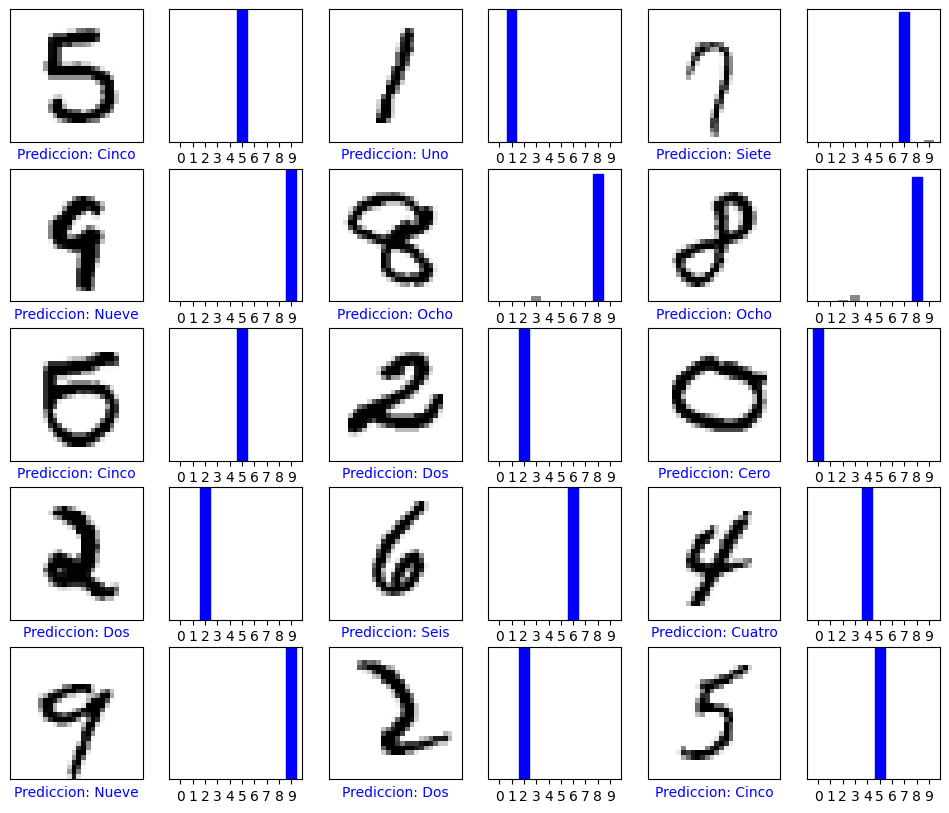

In [27]:
#Realizamos la grafica por cada imagen.
num_filas = 5
num_columnas = 3
num_imagenes = num_filas*num_columnas
plt.figure(figsize=(2*2*num_columnas, 2*num_filas))
for i in range(num_imagenes):
  plt.subplot(num_filas, 2*num_columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(num_filas, 2*num_columnas, 2*i+2)
  graficar_valores_predicciones(i, predicciones, etiquetas_prueba)
plt.show()